# Fase 2: DQN y PPO en Duckietown


En la Fase 1 resolvimos FrozenLake con Q-Learning tabular: 64 estados, una tabla que cabe entera en memoria. El problema de escalar es evidente: en Duckietown la observación es una imagen de cámara de 120×160×3. Eso equivale a un espacio de estados prácticamente infinito; no cabe ninguna tabla.

La solución es reemplazar la tabla por una **red neuronal** que aprenda a mapear imágenes a valores Q directamente. Eso es Deep RL, y es lo que hacemos en esta fase con dos algoritmos baseline:

| Algoritmo | Tipo | Acciones | Idea clave |
|-----------|------|----------|-----------|
| **DQN** | off-policy | discretas (5) | Replay buffer + red objetivo |
| **PPO** | on-policy | continuas | Objetivo recortado (clipped surrogate) |

Entrenamos sobre 5 mapas distintos para que el agente aprenda a generalizar en lugar de memorizar un circuito. El mapa de evaluación del profesor (`loop_obstacles`) no se usa en ningún momento.

> **Importante:** ejecutar en **Google Colab con GPU activada** (`Entorno de ejecución → T4 GPU`). Duckietown usa OpenGL para renderizar, que no funciona en Windows sin display virtual.


---

### Setup

Instalamos las dependencias del sistema y de Python en Colab, arrancamos la pantalla virtual que necesita OpenGL, e importamos todo lo necesario. En local estas líneas se saltan automáticamente.


In [8]:
import sys, os, pathlib, warnings, logging, subprocess
warnings.filterwarnings("ignore")
logging.disable(logging.INFO)
os.environ["PYTHONWARNINGS"] = "ignore"

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # dependencias de sistema para OpenGL headless
    os.system("sudo apt-get install -y -qq xvfb libosmesa6-dev libgl1-mesa-dri "
              "libgl1-mesa-glx libglu1-mesa libturbojpeg > /dev/null")

    # step 1: herramientas de build (setuptools provee distutils en Python 3.12)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "--upgrade", "pip", "setuptools>=68", "wheel"])

    # step 2: SB3 y utilidades
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "stable-baselines3[extra]", "opencv-python", "pyvirtualdisplay"])

    # step 3: dependencias de gym-duckietown instaladas MANUALMENTE.
    # gym-duckietown pide numpy<=1.20.0 en setup.py, que no existe para Python 3.12.
    # Instalamos las dependencias reales de runtime aqui y luego el paquete con --no-deps.
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "gym==0.26.2",       # API antigua requerida por duckietown
                           "pyglet>=1.5,<2.0",  # motor grafico
                           "PyYAML", "Pillow", "pyzmq",
                           "zuper-commons-z6",  # sistema de tipos duckietown
                           "PyGeometry-z6",     # geometria duckietown
                           "carnivalmirror"])

    # step 4: gym-duckietown sin resolver sus dependencias (evita numpy<=1.20)
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "--no-build-isolation", "--no-deps",
                           "git+https://github.com/duckietown/gym-duckietown.git@daffy"])

    from pyvirtualdisplay import Display
    Display(visible=False, size=(1024, 768)).start()
    print("Display virtual iniciado.")

import numpy as np
import cv2
import torch
import torch.nn as nn
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display
import gymnasium as gym
import gym as old_gym        # gym-duckietown usa la API antigua (gym 0.25)
from gymnasium import spaces
from stable_baselines3 import DQN, PPO
from stable_baselines3.common.vec_env import (
    DummyVecEnv, SubprocVecEnv, VecFrameStack, VecMonitor
)
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from stable_baselines3.common.callbacks import BaseCallback

# ruta robusta independiente del CWD de Jupyter/Colab
_cwd = pathlib.Path(os.path.abspath(""))
RESULTS = (_cwd.parent if _cwd.name == "notebooks" else _cwd) / "results" / "Fase_2"
RESULTS.mkdir(parents=True, exist_ok=True)

SEED      = 42
IMG_SIZE  = 64
N_STACK   = 4
TIMESTEPS = 30_000   # test rapido; subir a 200_000+ para resultados reales

TRAIN_MAPS = [
    "Duckietown-loop_empty-v0",
    "Duckietown-udem1-v0",
    "Duckietown-zigzag_dists-v0",
    "Duckietown-small_loop-v0",
    "Duckietown-straight_road-v0",
]

DISCRETE_ACTIONS = np.array([
    [0.6, 0.6],   # recto
    [0.35, 0.6],  # giro suave izquierda
    [0.6, 0.35],  # giro suave derecha
    [0.2, 0.6],   # giro fuerte izquierda
    [0.6, 0.2],   # giro fuerte derecha
], dtype=np.float32)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Resultados en: {RESULTS.resolve()}")
print(f"Dispositivo:   {device}")


Resultados en: C:\Users\Equipo\Desktop\ML2\Aprendizaje-por-Refuerzo-y-Conducci-n-Aut-noma\results\Fase_2
Dispositivo:   cpu


---

### Preprocesado y arquitectura

Antes de entrenar resolvemos dos problemas: el entorno usa la API antigua de `gym` y produce imágenes de 120×160×3; SB3 espera la API `gymnasium` y tensores compactos.

**`DuckieWrapper`** — adapta la API y preprocesa la observación:
1. Recortar el 50 % superior (el cielo no aporta información para seguir el carril)
2. Convertir a escala de grises (la geometría de la carretera no necesita color)
3. Redimensionar a 64×64 (suficiente detalle, mucho más rápido de procesar)

**Frame stacking (4 frames):** un frame estático no contiene información de movimiento. Al apilar 4 frames consecutivos la observación final es `(4, 64, 64)` y el agente puede inferir velocidad y dirección del giro.

**`DiscreteWrapper`** — DQN exige acciones discretas. Mapeamos 5 combinaciones de velocidades de rueda al espacio `{0..4}`. Es una simplificación: el agente no puede ejecutar giros de precisión arbitraria.

**`CustomCNN`** (Nature CNN, Mnih 2015): tres capas convolucionales que extraen la geometría de la carretera, seguidas de una capa lineal que produce un vector de 256 dimensiones. Ese vector alimenta las cabezas de política/valor de DQN y PPO.


In [9]:
import platform

class DuckieWrapper(gym.Env):
    metadata = {"render_modes": ["rgb_array"]}

    def __init__(self, env_name="Duckietown-loop_empty-v0", seed=None):
        super().__init__()
        import gym_duckietown          # registra los entornos al importar
        logging.disable(logging.INFO)  # gym-duckietown reactiva sus loggers al importar
        self.env = old_gym.make(env_name)
        if seed is not None:
            try: self.env.seed(seed)
            except Exception: pass
        self.action_space      = spaces.Box(-1.0, 1.0, shape=(2,), dtype=np.float32)
        self.observation_space = spaces.Box(0, 255, shape=(1, IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        obs = self.env.reset()
        return self._process(obs[0] if isinstance(obs, tuple) else obs), {}

    def step(self, action):
        obs, reward, done, info = self.env.step(np.asarray(action, dtype=np.float32).reshape(-1))
        return self._process(obs), float(reward), bool(done), False, info

    def _process(self, obs):
        # recortar cielo (50% superior) -> grises -> 64x64 -> canal unico
        obs = obs[obs.shape[0] // 2:]
        gray = cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)
        return np.expand_dims(
            cv2.resize(gray, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA), 0
        ).astype(np.uint8)

    def render(self): return self.env.render(mode="rgb_array")
    def close(self): self.env.close()


class DiscreteWrapper(gym.ActionWrapper):
    def __init__(self, env):
        super().__init__(env)
        self.action_space = spaces.Discrete(len(DISCRETE_ACTIONS))
    def action(self, a): return DISCRETE_ACTIONS[int(a)]


class LaneFollowingReward(gym.Wrapper):
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        # penalizar salirse (-10) y premiar cada paso en marcha (+0.1)
        shaped = -10.0 if (terminated and reward < 0) else reward
        return obs, shaped + 0.1, terminated, truncated, info


class CustomCNN(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=256):
        super().__init__(observation_space, features_dim)
        n_ch = observation_space.shape[0]
        self.cnn = nn.Sequential(
            nn.Conv2d(n_ch, 32, kernel_size=8, stride=4), nn.ReLU(),
            nn.Conv2d(32,  64, kernel_size=4, stride=2), nn.ReLU(),
            nn.Conv2d(64,  64, kernel_size=3, stride=1), nn.ReLU(),
            nn.Flatten(),
        )
        with torch.no_grad():
            n_flat = self.cnn(torch.as_tensor(observation_space.sample()[None]).float()).shape[1]
        self.linear = nn.Sequential(nn.Linear(n_flat, features_dim), nn.ReLU())

    def forward(self, x):
        return self.linear(self.cnn(x.float() / 255.0))


POLICY_KWARGS = dict(
    features_extractor_class=CustomCNN,
    features_extractor_kwargs=dict(features_dim=256),
)


def make_env(map_name, discrete=False, seed=SEED):
    def _init():
        env = LaneFollowingReward(DuckieWrapper(map_name, seed=seed))
        if discrete:
            env = DiscreteWrapper(env)
        return env
    return _init


def make_vec_env(maps, discrete=False):
    fns = [make_env(m, discrete=discrete, seed=SEED + i) for i, m in enumerate(maps)]
    if platform.system() == "Windows":
        # SubprocVecEnv requiere spawn de subprocesos, lo que no funciona dentro de un
        # kernel de Jupyter en Windows (los workers no pueden importar el contexto del
        # notebook y la pipe se rompe). Usamos DummyVecEnv como alternativa.
        # Nota: Duckietown necesita OpenGL; si no hay display disponible fallara aqui.
        print(f"[Windows] DummyVecEnv con {len(fns)} entorno(s) en proceso unico.")
        vec = DummyVecEnv(fns)
    elif len(fns) == 1:
        vec = DummyVecEnv(fns)
    else:
        # SubprocVecEnv: cada mapa en su proceso (contexto OpenGL independiente)
        vec = SubprocVecEnv(fns, start_method="spawn")
    return VecMonitor(VecFrameStack(vec, n_stack=N_STACK))


def _duckietown_available():
    """Comprueba si Duckietown puede ejecutarse en este entorno."""
    if platform.system() == "Windows":
        # EGL (requerido por pyglet/duckietown) no existe en Windows.
        # No hay workaround posible sin WSL2.
        print()
        print("=" * 62)
        print(" Duckietown no funciona en Windows.")
        print()
        print(" Causa: pyglet necesita la libreria EGL (OpenGL de Linux).")
        print(" Solucion: ejecuta este notebook en Google Colab con GPU.")
        print()
        print("   1. Abre el notebook en https://colab.research.google.com")
        print("   2. Entorno de ejecucion -> Cambiar tipo -> T4 GPU")
        print("   3. Ejecuta las celdas en orden desde el principio")
        print("=" * 62)
        print()
        return False
    try:
        import gym_duckietown  # noqa: F401
        return True
    except Exception as e:
        print(f"
Duckietown no disponible: {e}
")
        return False


print("Clases definidas correctamente.")


Clases definidas correctamente.


---

### Celda 2b — ¿Qué ve la cámara?

Visualizamos el pipeline de visión paso a paso con una imagen sintética de carretera. Funciona en local sin necesitar el simulador — en Colab se puede sustituir por un frame real de Duckietown.


Guardado: c:\Users\Equipo\Desktop\ML2\Aprendizaje-por-Refuerzo-y-Conducci-n-Aut-noma\results\Fase_2\vision_pipeline.png


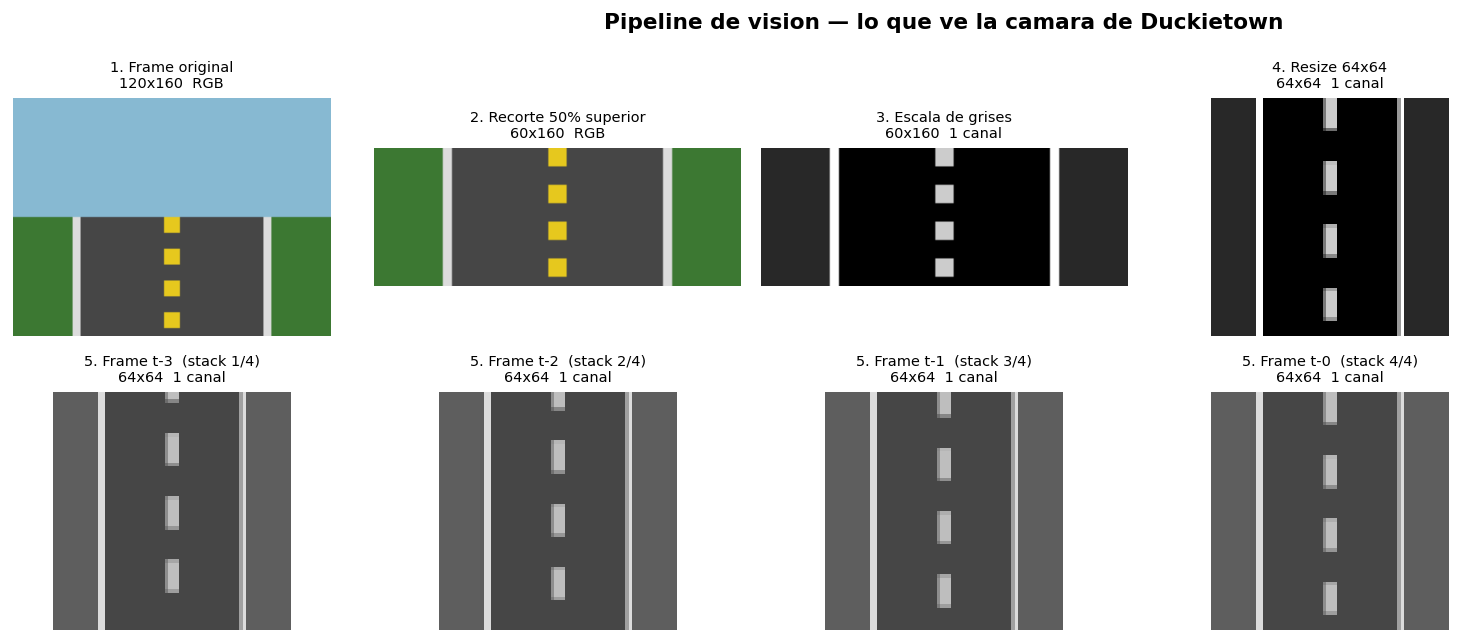


Forma final del tensor: 4 x 64 x 64  ->  (4, 64, 64)
CustomCNN recibe un batch de forma (N, 4, 64, 64)


In [10]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# imagen sintetica que imita un frame tipico de Duckietown (120x160x3 RGB)
H, W = 120, 160
frame = np.zeros((H, W, 3), dtype=np.uint8)

# cielo (azul claro) en la mitad superior
frame[:H//2, :] = [135, 185, 210]
# cesped a los lados de la carretera
frame[H//2:, :30]  = [60, 120, 50]
frame[H//2:, 130:] = [60, 120, 50]
# asfalto (gris oscuro)
frame[H//2:, 30:130] = [70, 70, 70]
# linea central amarilla discontinua
for y in range(H//2, H, 16):
    frame[y:y+8, 76:84] = [230, 200, 30]
# bordillos blancos
frame[H//2:, 30:34]   = [220, 220, 220]
frame[H//2:, 126:130] = [220, 220, 220]

# --- pipeline paso a paso ---
cropped = frame[H//2:, :, :]                                           # paso 1: recortar cielo
gray    = cv2.cvtColor(cropped, cv2.COLOR_RGB2GRAY)                    # paso 2: grises
resized = cv2.resize(gray, (64, 64), interpolation=cv2.INTER_AREA)     # paso 3: 64x64

# paso 4: simular 4 frames consecutivos (el coche avanza ligeramente entre ellos)
frames_stack = []
for shift in [6, 4, 2, 0]:
    f = np.roll(resized, -shift, axis=0).copy()
    if shift > 0:
        f[-shift:, :] = resized[-1, :]
    frames_stack.append(f)

# --- figura ---
fig = plt.figure(figsize=(15, 5))
fig.suptitle("Pipeline de vision — lo que ve la camara de Duckietown", fontweight="bold", fontsize=12)

steps   = ["1. Frame original\n120x160  RGB", "2. Recorte 50% superior\n60x160  RGB",
           "3. Escala de grises\n60x160  1 canal", "4. Resize 64x64\n64x64  1 canal"]
imgs    = [frame, cropped, gray, resized]
cmaps   = [None, None, "gray", "gray"]

for i, (img, title, cmap) in enumerate(zip(imgs, steps, cmaps), 1):
    ax = fig.add_subplot(2, 5, i)
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=8)
    ax.axis("off")

for j, f in enumerate(frames_stack):
    ax = fig.add_subplot(2, 5, 6 + j)
    ax.imshow(f, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"5. Frame t-{3-j}  (stack {j+1}/4)\n64x64  1 canal", fontsize=8)
    ax.axis("off")

plt.tight_layout()
p = RESULTS / "vision_pipeline.png"
plt.savefig(p, dpi=130, bbox_inches="tight"); plt.close()
print(f"Guardado: {p}"); display(Image(str(p)))
print(f"\nForma final del tensor: {len(frames_stack)} x 64 x 64  ->  (4, 64, 64)")
print("CustomCNN recibe un batch de forma (N, 4, 64, 64)")


---

### Celda 3 — DQN (baseline discreto)

**Deep Q-Network** extiende Q-Learning a observaciones de alta dimensión con dos mecanismos que estabilizan el entrenamiento:

- **Replay buffer:** almacenamos experiencias pasadas y muestreamos mini-batches aleatorios en lugar de aprender de cada transición en el momento. Rompe la correlación temporal entre pasos consecutivos, que es la causa principal de inestabilidad en Q-Learning con redes.
- **Red objetivo** (target network): mantenemos una copia congelada de la red Q y la sincronizamos solo cada `target_update_interval` pasos. Sin esto, el target `r + γ·max Q(s',·)` cambia en cada actualización y el aprendizaje diverge.

La limitación es que DQN exige acciones discretas. Con 5 acciones fijas el agente nunca puede hacer un giro de precisión: tiene que aproximarlo encadenando giros suaves y fuertes.

Hiperparámetros: `lr=1e-4`, `buffer=50k`, `batch=64`, `γ=0.99`, `exploration_fraction=0.2`.


In [11]:
class RewardLogger(BaseCallback):
    def __init__(self):
        super().__init__(verbose=0)
        self.ep_rewards = []
    def _on_step(self):
        # VecMonitor añade "episode" al info dict cuando termina un episodio
        for info in self.locals.get("infos", []):
            if "episode" in info:
                self.ep_rewards.append(info["episode"]["r"])
        return True


def train_dqn():
    env = make_vec_env(TRAIN_MAPS, discrete=True)
    model = DQN(
        "CnnPolicy", env,
        policy_kwargs          = POLICY_KWARGS,
        learning_rate          = 1e-4,
        buffer_size            = 50_000,
        learning_starts        = 1_000,
        batch_size             = 64,
        gamma                  = 0.99,
        train_freq             = 4,
        target_update_interval = 1_000,
        exploration_fraction   = 0.2,
        exploration_final_eps  = 0.05,
        verbose = 1,
        seed    = SEED,
        device  = device,
    )
    cb = RewardLogger()
    model.learn(total_timesteps=TIMESTEPS, callback=cb)
    model.save(str(RESULTS / "dqn_duckie"))
    env.close()
    return model, cb.ep_rewards


if _duckietown_available():
    dqn_model, dqn_ep_rewards = train_dqn()

    if dqn_ep_rewards:
        ma = np.convolve(dqn_ep_rewards, np.ones(20) / 20, mode="valid")
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(ma, color="steelblue")
        ax.axhline(ma[-1], color="tomato", linestyle="--", label=f"Final: {ma[-1]:.1f}")
        ax.set(xlabel="Episodio", ylabel="Recompensa (media movil 20)",
               title="DQN — curva de entrenamiento en Duckietown")
        ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
        p = RESULTS / "dqn_training.png"
        plt.savefig(p, dpi=120, bbox_inches="tight"); plt.close()
        print(f"Guardado: {p}"); display(Image(str(p)))
    else:
        print("DQN entrenado (sin episodios completos en el buffer).")
else:
    dqn_model, dqn_ep_rewards = None, []


{'audio': ('xaudio2', 'directsound', 'openal', 'pulse', 'silent'), 'debug_font': False, 'debug_gl': True, 'debug_gl_trace': False, 'debug_gl_trace_args': False, 'debug_graphics_batch': False, 'debug_lib': False, 'debug_media': False, 'debug_texture': False, 'debug_trace': False, 'debug_trace_args': False, 'debug_trace_depth': 1, 'debug_trace_flush': True, 'debug_win32': False, 'debug_x11': False, 'graphics_vbo': True, 'shadow_window': True, 'vsync': None, 'xsync': True, 'xlib_fullscreen_override_redirect': False, 'darwin_cocoa': True, 'search_local_libs': True, 'advanced_font_features': False, 'headless': False, 'headless_device': 0, 'win32_disable_shaping': False}
[Windows] DummyVecEnv con 5 entorno(s) en proceso unico.


ImportError: Library "EGL" not found.

**¿Qué vemos?**

Al principio la recompensa es muy negativa: el agente sale de la carretera constantemente y acumula penalizaciones de -10. A medida que el buffer se llena y ε decrece, el agente aprende a mantenerse en el carril y la recompensa sube. Con 30k pasos vemos el inicio del aprendizaje — para convergencia real hacen falta 200k+ en GPU.

La limitación de las 5 acciones discretas se nota en curvas cerradas: el agente tiene que encadenar varios giros fuertes donde un control continuo haría un solo movimiento progresivo.


---

### Celda 4 — PPO (baseline continuo)

**Proximal Policy Optimization** opera directamente sobre acciones continuas — no necesita `DiscreteWrapper`. Su innovación es el **objetivo recortado** (*clipped surrogate*):

```
L_CLIP = E[ min( r_t · A_t ,  clip(r_t, 1−ε, 1+ε) · A_t ) ]
```

El ratio `r_t = π(a|s) / π_old(a|s)` mide cuánto ha cambiado la política desde la última actualización. Si el cambio es excesivo, el clip lo limita. Esto evita actualizaciones destructivas y hace PPO muy estable en la práctica.

Con acciones continuas el agente puede ejecutar exactamente el giro que necesita, produciendo conducción más suave que DQN. El precio es que PPO es **on-policy**: descarta todas las experiencias tras cada actualización, lo que lo hace menos eficiente en muestras.

Hiperparámetros: `lr=3e-4`, `n_steps=2048`, `batch=256`, `n_epochs=10`, `γ=0.99`, `gae_λ=0.95`, `clip=0.2`, `ent_coef=0.01`.


In [ ]:
def train_ppo():
    env = make_vec_env(TRAIN_MAPS, discrete=False)
    model = PPO(
        "CnnPolicy", env,
        policy_kwargs = POLICY_KWARGS,
        learning_rate = 3e-4,
        n_steps       = 2_048,
        batch_size    = 256,
        n_epochs      = 10,
        gamma         = 0.99,
        gae_lambda    = 0.95,
        clip_range    = 0.2,
        ent_coef      = 0.01,
        verbose = 1,
        seed    = SEED,
        device  = device,
    )
    cb = RewardLogger()
    model.learn(total_timesteps=TIMESTEPS, callback=cb)
    model.save(str(RESULTS / "ppo_duckie"))
    env.close()
    return model, cb.ep_rewards


if _duckietown_available():
    ppo_model, ppo_ep_rewards = train_ppo()

    if ppo_ep_rewards:
        ma = np.convolve(ppo_ep_rewards, np.ones(20) / 20, mode="valid")
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(ma, color="seagreen")
        ax.axhline(ma[-1], color="tomato", linestyle="--", label=f"Final: {ma[-1]:.1f}")
        ax.set(xlabel="Episodio", ylabel="Recompensa (media movil 20)",
               title="PPO — curva de entrenamiento en Duckietown")
        ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
        p = RESULTS / "ppo_training.png"
        plt.savefig(p, dpi=120, bbox_inches="tight"); plt.close()
        print(f"Guardado: {p}"); display(Image(str(p)))
    else:
        print("PPO entrenado.")
else:
    ppo_model, ppo_ep_rewards = None, []


**¿Qué vemos?**

PPO suele mostrar una curva más suave que DQN porque el gradiente de política es más estable. Al tener acciones continuas el agente puede ajustar gradualmente sus giros en lugar de saltar entre categorías discretas. La contrapartida es que necesita acumular `n_steps=2048` experiencias antes de cada actualización, lo que puede hacer que arranque más lento con el mismo presupuesto de pasos.


---

### Celda 5 — Evaluación comparativa

Evaluamos ambos modelos en modo determinista (sin exploración) sobre los 5 mapas de entrenamiento. El mejor agente continuo se guarda como `best_duckie_agent.zip`, que es el fichero que cargará el profesor en la evaluación final.


In [ ]:
def evaluate_agent(model, discrete=False, n_episodes=5):
    env = make_vec_env(TRAIN_MAPS, discrete=discrete)
    returns = []
    for _ in range(n_episodes):
        obs = env.reset()
        done = np.array([False])
        ep_ret, steps = 0.0, 0
        while not done[0] and steps < 1000:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, _ = env.step(action)
            ep_ret += float(reward[0]); steps += 1
        returns.append(ep_ret)
    env.close()
    return float(np.mean(returns)), float(np.std(returns)), returns


dqn_mean, dqn_std, dqn_ret = evaluate_agent(dqn_model, discrete=True)
ppo_mean, ppo_std, ppo_ret = evaluate_agent(ppo_model, discrete=False)

# guardar el mejor agente continuo (PPO aqui; en Fase 3 sera SAC)
ppo_model.save("best_agent")
print("best_agent.zip guardado.")

# grafica comparativa
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(["DQN (discreto)", "PPO (continuo)"],
              [dqn_mean, ppo_mean],
              yerr=[dqn_std, ppo_std],
              capsize=8, color=["steelblue", "seagreen"], alpha=0.85)
for bar, m in zip(bars, [dqn_mean, ppo_mean]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(dqn_std, ppo_std) * 0.15 + 0.5,
            f"{m:.1f}", ha="center", va="bottom", fontweight="bold")
ax.set(ylabel="Recompensa media (5 episodios)",
       title=f"DQN vs PPO — {TIMESTEPS:,} timesteps")
ax.grid(axis="y", alpha=0.3); plt.tight_layout()
p = RESULTS / "dqn_vs_ppo.png"
plt.savefig(p, dpi=120, bbox_inches="tight"); plt.close()
print(f"Guardado: {p}"); display(Image(str(p)))

print(f"\nDQN: {dqn_mean:.2f} +/- {dqn_std:.2f} | retornos: {[round(x,1) for x in dqn_ret]}")
print(f"PPO: {ppo_mean:.2f} +/- {ppo_std:.2f} | retornos: {[round(x,1) for x in ppo_ret]}")


**Conclusiones de la Fase 2**

Esta fase demuestra que es posible aprender a conducir desde píxeles: algo impensable con la Q-Table de la Fase 1. Con 30k pasos vemos los primeros pasos del aprendizaje, no el rendimiento final.

Las diferencias estructurales entre los dos algoritmos ya se aprecian aunque no haya convergencia:

- **DQN** arranca más rápido gracias al replay buffer, pero su techo está limitado por la discretización. En curvas cerradas tiene que encadenar varias acciones discretas donde un control continuo haría un solo movimiento progresivo.
- **PPO** produce conducción más suave al operar en el espacio continuo, pero al ser on-policy necesita más pasos para aprovechar cada experiencia.

Estos dos resultados son la **referencia** para la Fase 3. La hipótesis es que **SAC** superará a PPO al ser off-policy (reutiliza experiencias como DQN) y a DQN al usar control continuo (como PPO), añadiendo exploración por máxima entropía que genera políticas más robustas en el mapa oculto.
